# In-Class Example: Recommender Systems

## Content-based filtering with a cold start

Several project groups are interested in making recommendations to users, but find themselves only in possession of a **database of things to recommend**, with **no user information**. For example, suppose you want to create a tool that can match users up with the best-fitting job applications (the example we mentioned in class), but you only have the data on the job applications, not on the users. In this notebook, we'll explore one version of what your project might look like.

We're going to work with the dataset below, from [this Kaggle link](https://www.kaggle.com/datasets/madhab/jobposts). First we import the libraries that we plan on using:

In [3]:
import pandas as pd
import numpy as nm
import missingno as nomiss
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Dataset

We'll read in the dataset and take a look at the first few rows to get an idea of what types ov variables we have to work with. This dataset has about 19,000 job postings that were posted through the Armenian human resource portal CareerCenter. It was extracted from a Yahoo mailing group. The job posts were made between 2004 and 2015.

In [4]:
jobs = pd.read_csv('data job posts.csv')
# view the first few rows
jobs.head()

,jobpost,date,Title,Company,AnnouncementCode,Term,Eligibility,Audience,StartDate,Duration,...,Salary,ApplicationP,OpeningDate,Deadline,Notes,AboutC,Attach,Year,Month,IT
0,AMERIA Investment Consulting Company\r\nJOB TI...,"Jan 5, 2004",Chief Financial Officer,AMERIA Investment Consulting Company,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"To apply for this position, please submit a\r\...",NaN,26 January 2004,NaN,NaN,NaN,2004,1,False
1,International Research & Exchanges Board (IREX...,"Jan 7, 2004",Full-time Community Connections Intern (paid i...,International Research & Exchanges Board (IREX),NaN,NaN,NaN,NaN,NaN,3 months,...,NaN,Please submit a cover letter and resume to:\r\...,NaN,12 January 2004,NaN,The International Research & Exchanges Board (...,NaN,2004,1,False
2,Caucasus Environmental NGO Network (CENN)\r\nJ...,"Jan 7, 2004",Country Coordinator,Caucasus Environmental NGO Network (CENN),NaN,NaN,NaN,NaN,NaN,Renewable annual contract\r\nPOSITION,...,NaN,Please send resume or CV toursula.kazarian@......,NaN,20 January 2004\r\nSTART DATE: February 2004,NaN,The Caucasus Environmental NGO Network is a\r\...,NaN,2004,1,False
3,Manoff Group\r\nJOB TITLE: BCC Specialist\r\n...,"Jan 7, 2004",BCC Specialist,Manoff Group,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Please send cover letter and resume to Amy\r\n...,NaN,23 January 2004\r\nSTART DATE: Immediate,NaN,NaN,NaN,2004,1,False
4,Yerevan Brandy Company\r\nJOB TITLE: Software...,"Jan 10, 2004",Software Developer,Yerevan Brandy Company,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Successful candidates should submit\r\n- CV; \...,NaN,"20 January 2004, 18:00",NaN,NaN,NaN,2004,1,True


From `head` alone, we see that there is a considerable amount of missingness. We can look at a summary of the variables using `describe`, which may give us some more information:

In [5]:
jobs.describe(include='all')

,jobpost,date,Title,Company,AnnouncementCode,Term,Eligibility,Audience,StartDate,Duration,...,Salary,ApplicationP,OpeningDate,Deadline,Notes,AboutC,Attach,Year,Month,IT
count,19001,19001,18973,18994,1208,7676,4930,640,9675,10798,...,9622,18941,18295,18936,2211,12470,1559,19001.000000,19001.000000,19001
unique,18892,4391,8636,4554,1014,411,663,216,1186,1515,...,2692,14187,3344,5202,1031,6016,1495,NaN,NaN,2
top,Career Center NGO\r\nTITLE: English Language ...,"May 6, 2014",Accountant,ArmenTel CJSC,IOS - 001,Full time,All qualified candidates,All interested candidates,ASAP,Long term,...,Competitive,"To apply for this position, please open\r\nwww...",17 July 2009,Open,Should you have any questions regarding regist...,Mentor Graphics Development Services CJSC is a...,The following attachment(s) to this announceme...,NaN,NaN,False
freq,11,24,328,353,9,5348,1223,105,4754,3458,...,1298,68,25,103,129,196,21,NaN,NaN,15242
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.274722,6.493869,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.315609,3.405503,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.000000,3.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,7.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,9.000000,NaN


Let's look at a bar chart to assess which variables have the most missing values. This package, `missingno`, is the Python version of `naniar`, and it has a function `bar()` that will show us the information we want. The bars represent the proportion of that variable that is *not* missing. From the below plot, we can see that date, title, and posting information have very little, if any, missingness. Some variables are more than 50% missing, however. We will likely want to drop those.

<Axes: >

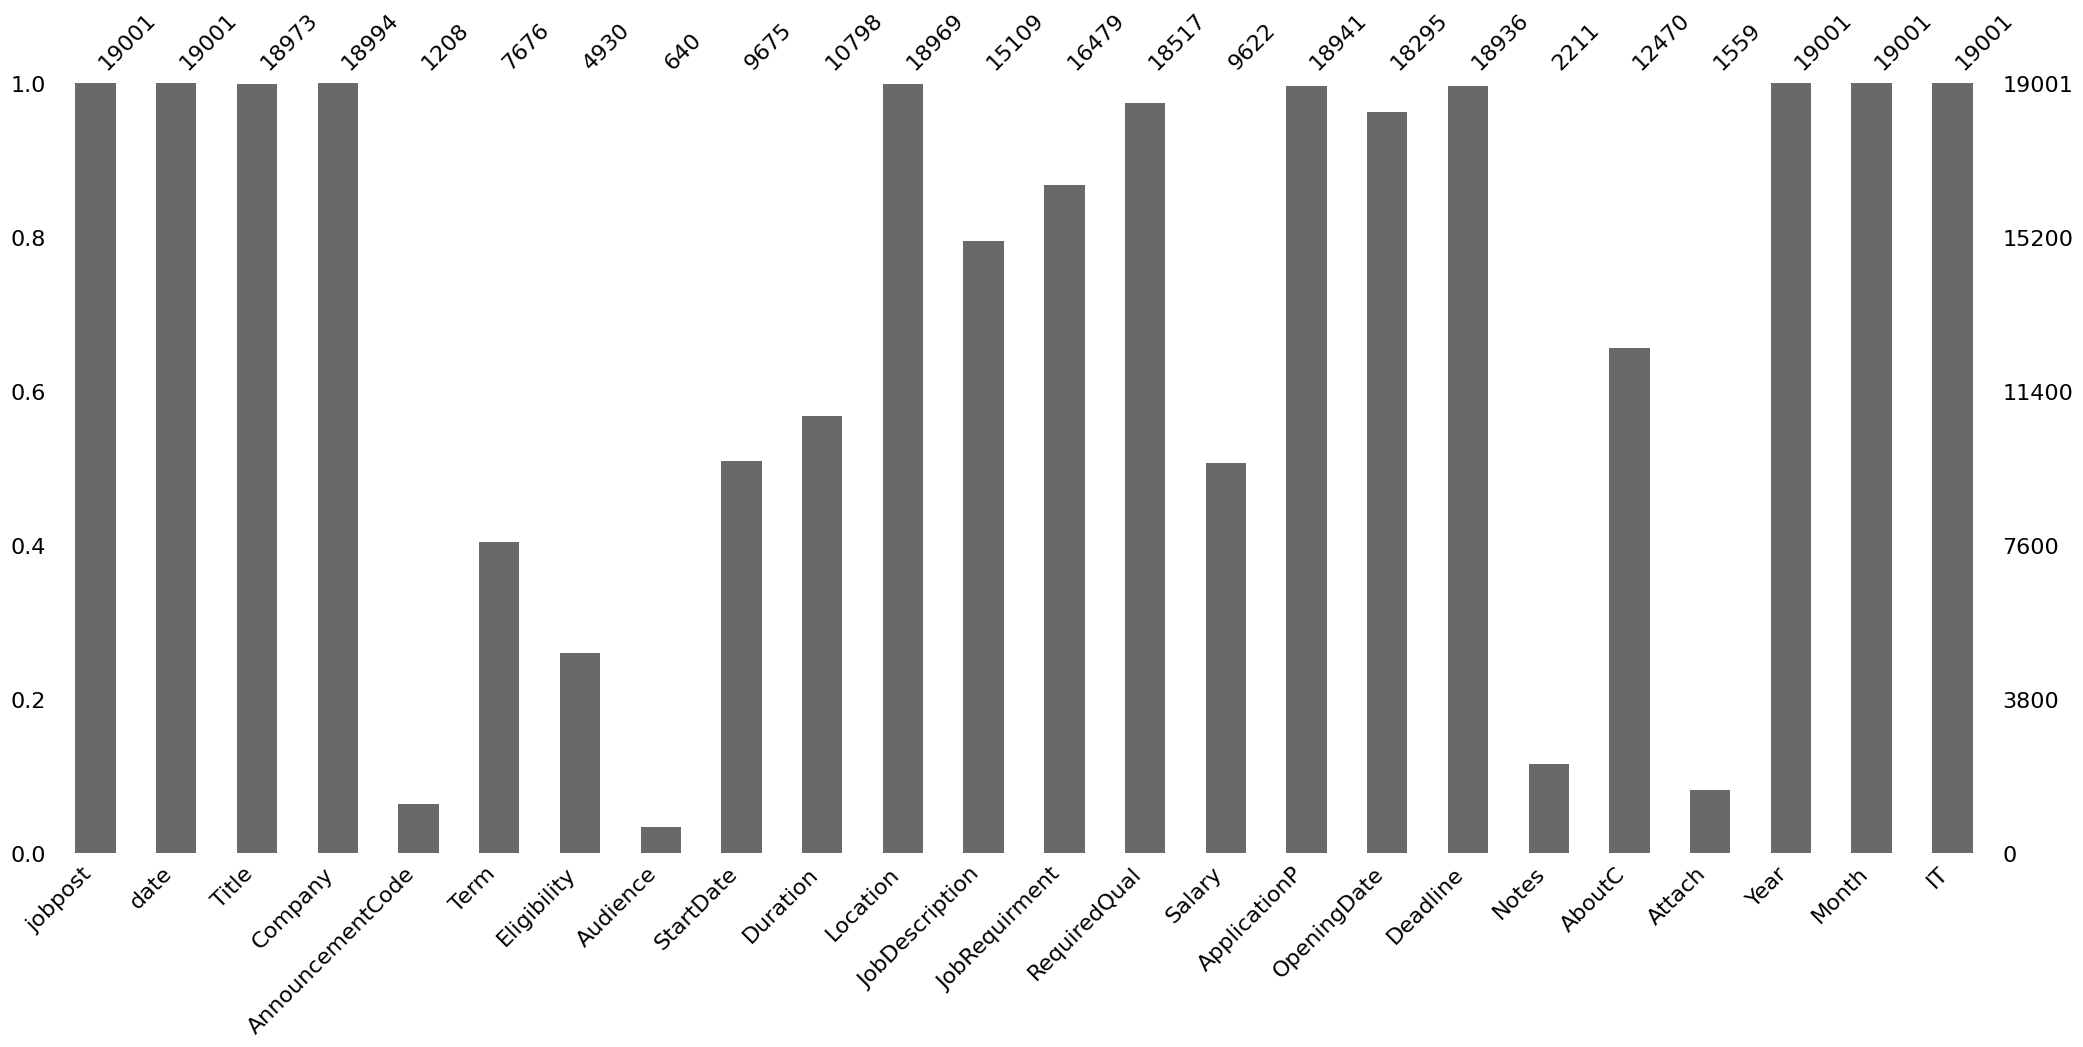

In [6]:
nomiss.bar(jobs)

The following code will drop any columns with more than 50\% missingness. We first calculate the number of observations that represents 50\% of the dataset and store it as `threshold`, then use that number to drop the appropriate columns.

In [7]:
threshold = len(jobs) * 0.5
jobs_cleaned = jobs.dropna(axis = 1, thresh = threshold)

Then, for simplicity's sake here, we're going to go ahead and also drop any rows with missing values. This is going to dramatically reduce the size of the dataset, and wouldn't be the gold standard choice of procedure, but for the purposes of this demonstration (and since we will still have thousands of job postings remaining), it is the fastest option.

We didn't do this first because dropping any rows with missing values initially, before restricting the space to those variables with < 50\% missingness, would have actually reduced the dataset to zero rows.

In [8]:
jobs_cleaned = jobs_cleaned.dropna(axis = 0)

Now we still have 3,110 rows, as seen below:

In [9]:
jobs_cleaned

,jobpost,date,Title,Company,StartDate,Duration,Location,JobDescription,JobRequirment,RequiredQual,Salary,ApplicationP,OpeningDate,Deadline,AboutC,Year,Month,IT
320,Training and Development Ltd.\r\nTITLE: Train...,Jun 7 10:38 PM,Training Manager,Training and Development Ltd.,01 July 2004,Continuos,"Yerevan, Armenia",Assist Training Coordinator in performing a\r\...,- Create and distribute marketing materials to...,- Demonstrated experience creating presentatio...,salary offer will be commensurate with educati...,please send your cover letter and resume via\r...,01 July 2001,21 June 2004,"Established in 2001, the TRAINING & DEVELOPMEN...",2004,6,False
467,Lycos Armenia CJSC\r\nTITLE: JSP/Java Develop...,"Jul 28, 2004",JSP/Java Developer for Lycos Mail,Lycos Armenia CJSC,As soon as possible,Permanent,"Yerevan, Armenia",The role requires dedicated JSP/Java professio...,The key elements of the role are full life cyc...,- Technically the key skills are Web based tec...,Attractive,Please send your CV to info@....\r\nYou can al...,29 July 2004,31 August 2004,Lycos Europe is one of the leading European In...,2004,7,True
468,Lycos Armenia CJSC\r\nTITLE: Java/C++ Develop...,"Jul 28, 2004",Java/C++ Developer for Lycos Mail,Lycos Armenia CJSC,As soon as possible,Permanent,"Yerevan, Armenia",The role requires dedicated Java/C++ professio...,The key elements of the role are full life cyc...,- Technically the key skill requirements are J...,Attractive,Please send your CV to info@....\r\nYou can al...,29 July 2004,31 August 2004,Lycos Europe is one of the leading European In...,2004,7,True
471,Lycos Europe\r\nTITLE: Java/C++ Developer for...,"Jul 29, 2004",Java/C++ Developer for Lycos Communities,Lycos Europe,ASAP,Permanent,"Yerevan, Armenia",The role requires dedicated Java/C++ professio...,The key elements of the role are full life cyc...,- Technically the key skill requirements are J...,Attractive,Please send your CV to info@....\r\nYou can al...,29 July 2004,31 August 2004,Lycos Europe is one of the leading European In...,2004,7,True
472,Lycos Europe\r\nTITLE: JSP/Java Developer for...,"Jul 29, 2004",JSP/Java Developer for Lycos Chat,Lycos Europe,ASAP,Permanent,"Yerevan, Armenia",The role requires dedicated web developer\r\np...,The key elements of the role are full life cyc...,- Technically the key skills are Web based tec...,Attractive,Please send your CV to info@....\r\nYou can al...,29 July 2004,31 August 2004,Lycos Europe is one of the leading European In...,2004,7,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18979,Care Building Services LLC\r\n\r\n\r\nTITLE: ...,"Dec 23, 2015",Project Assistant,Care Building Services LLC,Immediately,Long-term,"Yerevan, Armenia",Care Building Services LLC is seeking a Projec...,"- Prepare project documents, paperwork and rep...","- Higher education diploma in Economics, Engin...",Highly competitive,"To apply for this position, please submit your...",23 December 2015,20 January 2016,Care Building Services LLC is a Yerevan based\...,2015,12,False
18983,Care Building Services LLC\r\n\r\n\r\nTITLE: ...,"Dec 23, 2015",Construction Site Manager,Care Building Services LLC,Immediately,Long-term,"Yerevan, Armenia",Care Building Services LLC is seeking an engin...,- Supervise the construction work on the site;...,- Engineering degree in the field of Civil Con...,Highly competitive,"To apply for this position, please submit your...",23 December 2015,20 January 2016,Care Building Services LLC is a Yerevan based\...,2015,12,False
18984,Care Building Services LLC\r\n\r\n\r\nTITLE: ...,"Dec 23, 2015",Electrical Engineer,Care Building Services LLC,Immediately,Long-term,"Yerevan, Armenia",Care Building Services is seeking an Electrica...,- Supervise a team of electricians on the site...,- Degree in Engineering or in a related field;...,Highly competitive,"To apply for this position, please submit your...",23 December 2015,20 January 2016,Care Building Services LLC is a Yerevan based

We may also note that the location for all the jobs visible here is the same -- Yerevan, Armenia. This makes sense, of course, because we know the data consist of job postings on an Armenian human resource portal. This relates to the generalizability of our recommender system; if we want to recommend jobs to users in many locations across the globe, we would need a database including job information from all those locations. For this course example, we will simply suppose our recommender system is intended only for *data scientists looking for jobs in Armenia*.

We have a lot of information in this dataset, and there's a lot of potential here to make recommendations.

If we were looking to create a user-facing application, we could imagine asking users for their preferences in terms of start date, duration, and salary. We would also likely want to obtain the date and time the user was making the search, then filter for open jobs before making recommendations.

For this, we're going to keep it simple. We'll start by doing the following:

1. Combine variables with job information into a long string per job (we'll call this a job profile vector);
2. Clean the text;
3. Apply TF-IDF to the job profile vectors.

### Creating job profile vectors

After visually inspecting the data above, it seems like the most relevant columns for our purposes are likely to be the job title, description, requirements, and the required qualifications. These are all text columns, so we will combine them into one long string, separated by spaces.

In [10]:
jobs_cleaned["combined_text"] = (
    jobs_cleaned["Title"] + " " + 
    jobs_cleaned["JobDescription"] + " " + 
    jobs_cleaned["JobRequirment"] + " " + 
    jobs_cleaned["RequiredQual"])

Next, let's look at an example string. This is for row 10. We display the first 1,500 characters:

In [11]:
jobs_cleaned["combined_text"].iloc[10][:1500]

'Advanced Java Developer for Lycos Communities The role requires dedicated Java/C++ professionals\r\nthat will enjoy applying the latest technologies for solving challenging\r\ntasks in a creative, professional environment of the Lycos Communities\r\nmultinational team. Current projects are dedicated to achieving our\r\nambitious goal of strengthening and expanding our premier position in\r\nEurope and becoming the Number One on-line chat in the World. The key elements of the role are full life cycle\r\nproduct development working in a technically strong team through\r\nrequirements gathering, architecture, development and release. The\r\ncandidate is required to work closely with the other technical members\r\nof the Lycos Communities teams. - Technically the key skill requirements are Java with at least 3 years\r\nexperience. \r\n- Additionally experience with some of the following would be desirable:\r\nLinux, Apache, MySQL, CVS. \r\n- Academic degree of a minimum BS is essential. \

This looks good! Row 10 is for a job that is looking for Java/C++ professionals. Now, though, we may want to flex our NLP skills a bit and see if we can clean this text up a little. If we go straight to TF-IDF or bag of words, we don't want to treat "\r" as a word, for example, or "\n". We don't want capitalization (because that would consider "Advanced" as different from "advanced," for example). So we'll write a function to clean up and process our text string.

In [12]:
def clean_text(text):

    # make everything lowercase
    text = text.lower()

    # drop HTML tags (replace them with blank space)
    text = re.sub(r"<.*?>", " ", text)

    # then replace those pesky \rs and \n-s with blank space
    text = re.sub(r"[\r\n\t]", " ", text)

    # remove punctuation (replace with nothing)
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    # strip any leading or trailing whitespace
    text = text.strip()

    return text

Now we apply this function to our text strings, and then we'll check the same example we looked at earlier, for comparison (and to verify that the pre-processing worked):

In [13]:
jobs_cleaned["cleaned_text"] = jobs_cleaned["combined_text"].apply(clean_text)
jobs_cleaned["cleaned_text"].iloc[10][:1500]

'advanced java developer for lycos communities the role requires dedicated javac professionals that will enjoy applying the latest technologies for solving challenging tasks in a creative professional environment of the lycos communities multinational team current projects are dedicated to achieving our ambitious goal of strengthening and expanding our premier position in europe and becoming the number one online chat in the world the key elements of the role are full life cycle product development working in a technically strong team through requirements gathering architecture development and release the candidate is required to work closely with the other technical members of the lycos communities teams technically the key skill requirements are java with at least 3 years experience additionally experience with some of the following would be desirable linux apache mysql cvs academic degree of a minimum bs is essential english knowledge is highly desired'

Looks good! We've cleaned the text and are ready to apply TF-IDF. Notice that our cleaning does lose some information and of course isn't perfect; for example, "Java/C++" has become "javac", which is not ideal. But overall, this looks like an improvement.

The below code tells Python first that we want to create a TF-IDF vectorizer object, which we will apply to the text strings. The vectorizer should build a vocabulary by tokenizing the strings into words and retaining all unique tokens. It should then remove common English stop words and filter to retain only the 15,000 most frequently occuring tokens (that is, the 15,000 tokens with the highest term frequency across the corpus). Lastly, it calculates the TF-IDF scores for each token. The result is a large, sparse matrix, where each column is a token, each row is a job string, and each observation is a TF-IDF score.

Note that we use `fit_transform()` here, but will use a different function later on. The reason is because we only want to create our vocabulary, or set of unique tokens, **once**. Later on we will calculate TF-IDF scores for some example users, and we want to make sure that users and jobs share the same word-to-column mapping.

In [29]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000
)
job_vectors = vectorizer.fit_transform(
    jobs_cleaned["cleaned_text"]
)

Let's check that it worked:

In [15]:
job_vectors

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 304093 stored elements and shape (3117, 11627)>

This is actually quite a large, sparse matrix, and yet Python can handle it with ease. Similar code in R would take considerably longer. And this dataset is nowhere near as large as it could be. Remember that we ended up reducing the number of job postings we're working with from about **19,000** down to a little over **3,000**.

### Calculating similarity between jobs

Technically, it's not necessary to calculate job-job similarity in order to generate content-based recommendations here. We ultimately will only be using **job-user** similarity to make recommendations. But it is a good initial demonstration, and will help us verify that the approach is sound.

Note that all we are doing here is creating TF-IDF vectors for these job strings, and then calculating the cosine similarity among these vectors. In other words, these strings:

- *"Seeking a data analyst to build predictive models, analyze customer behavior,
create dashboards, and generate business insights using Python, SQL, and machine
learning techniques. Experience with statistical modeling and reporting required."*

- *"Seeking a fraud analyst to monitor suspicious transactions, detect financial risk, generate compliance reports, and investigate fraudulent activity using Python, SQL, and machine learning techniques. Experience with statistical modeling and reporting required."*

will likely have a high TF-IDF cosine similarity, even though they are describing very different jobs. The key downside of using TF-IDF to calculate similarity is that strings may overlap heavily in terms of vocabulary used but may *mean* very different things. 

A better approach would be to create job vectors using word2vec and *then* calculate cosine similarity. If you want to practice your skills, you can try implementing that on this dataset.

The below code calculates cosine similarity for these TF-IDF vectors between jobs:

In [16]:
similarity_matrix = cosine_similarity(job_vectors)

Then we define a function, `recommend_similar_jobs`. This function will:

1. Take in a job index, identifying the job to start with;
2. Look up that job's row in the similarity matrix (which contains the similarity scores between that job and every other job in the dataset);
3. Pairs each similarity score with the corresponding job index;
4. Sorts job-score pairs from most similar to least similar;
5. Drops the first result (because the "most similar" job will be the job itself);
6. Keeps only the `top_n` (here, 5) remaining jobs;
7. Extracts the indices for those jobs;
8. Pulls the matching indices from `jobs_cleaned`;
9. Returns the title, company, and location for those jobs.

In [17]:
def recommend_similar_jobs(job_index, top_n=5):
    
    similarity_scores = list(enumerate(similarity_matrix[job_index]))
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    similarity_scores = similarity_scores[1:top_n+1]
    
    recommended_indices = [i[0] for i in similarity_scores]
    
    return jobs_cleaned.iloc[recommended_indices][
        ["Title", "Company", "Location"]
    ]

We'll test it. Let's look at the job with row index 10. What is that job?

In [18]:
jobs_cleaned.iloc[10]

jobpost           Lycos Europe\r\nTITLE:  Advanced Java Develope...
date                                                   Aug 13, 2004
Title                 Advanced Java Developer for Lycos Communities
Company                                                Lycos Europe
StartDate                                                      ASAP
Duration                                                  Permanent
Location                                           Yerevan, Armenia
JobDescription    The role requires dedicated Java/C++ professio...
JobRequirment     The key elements of the role are full life cyc...
RequiredQual      - Technically the key skill requirements are J...
Salary                                                   Attractive
ApplicationP      Please send your CV to info@....\r\nYou can al...
OpeningDate                                            29 July 2004
Deadline                                             31 August 2004
AboutC            Lycos Europe is one of the lea

That job posting is for an advanced Java developer for the Lycos Communities organization. Let's find the five most similar jobs using our function:

In [19]:
recommend_similar_jobs(10)

,Title,Company,Location
471,Java/C++ Developer for Lycos Communities,Lycos Europe,"Yerevan, Armenia"
472,JSP/Java Developer for Lycos Chat,Lycos Europe,"Yerevan, Armenia"
649,C++ Developer,Lycos Europe,"Yerevan, Armenia"
517,Advanced Java Developer for Lycos Billing Plat...,Lycos Europe,"Yerevan, Armenia"
650,PHP Developer for Lycos Hosting,Lycos Europe,"Yerevan, Armenia"


And our function returns the five most similar jobs, using TF-IDF and cosine similarity. These recommendations are all for developer jobs at Lycos Europe; three for Java developers, one for C++, and one for PHP. Pretty good! Let's try another. 

Here's the job with row index 100:

In [20]:
jobs_cleaned.iloc[100]

jobpost           CQGI MA\r\nTITLE:  C++/ C# Senior Developer\r\...
date                                                   Jan 31, 2005
Title                                      C++/ C# Senior Developer
Company                                                     CQGI MA
StartDate                                                      ASAP
Duration                                                  Permanent
Location                                           Yerevan, Armenia
JobDescription    The primary objective of this position is to p...
JobRequirment     - Gather and produce requirements and designs;...
RequiredQual      - Bachelors degree in Computer Science or rela...
Salary                                                Starting $800
ApplicationP      Please submit your resume to: mariya@...\r\nan...
OpeningDate                                         28 January 2005
Deadline                                                       Open
AboutC                                        We

A C++/C# senior developer at CQGI. Let's check out the similar jobs:

In [21]:
recommend_similar_jobs(100)

,Title,Company,Location
969,C++/ C# Senior Developer,CQGI MA,"Yerevan, Armenia"
17615,C++ Software Developer,CQGI MA LLC,"Yerevan, Armenia"
16575,Linux C++ Software Developer,CQGI MA LLC,"Yerevan, Armenia"
17621,Senior C++ Software Developer,CQGI MA LLC,"Yerevan, Armenia"
8705,"Senior Software Developer C#, C++, .Net",Smart-Tech LLC,"Yerevan, Armenia"


The five most similar jobs in terms of TF-IDF and cosine similarity are all C++ developer jobs! Good.

### Calculating similarity between jobs and users

Now we're going to generate some user data. 

In practice, you could imagine creating a form where users would type in their information, and then the app would run the above function to generate recommendations for the users. For a class project, developing an entire front end and recruiting users to beta test is just a **bit** too big of an ask. Instead, I generated the following simulated user information by asking an LLM to provide me with a dictionary of 5 user profiles for people who are interested in jobs in data science. This would be perfectly sufficient for a class project.

In [22]:
users = [
    {
        "name": "Alice",
        "skills": "python machine learning statistics pandas scikit-learn",
        "interests": "data science predictive modeling AI"
    },
    
    {
        "name": "Bob",
        "skills": "javascript react html css frontend",
        "interests": "web development UI UX"
    },
    
    {
        "name": "Carol",
        "skills": "SQL tableau dashboards business analytics",
        "interests": "data visualization business intelligence"
    },

    {
        "name": "David",
        "skills": "cybersecurity linux networking encryption penetration testing cloud security",
        "interests": "information security infrastructure system administration threat analysis"
    },

    {
        "name": "Eva",
        "skills": "biology genomics r python bioinformatics statistical analysis laboratory research",
        "interests": "healthcare medical research genetics computational biology public health"
    }
]

Let's double-check that the information looks as it should:

In [23]:
users

[{'name': 'Alice',
  'skills': 'python machine learning statistics pandas scikit-learn',
  'interests': 'data science predictive modeling AI'},
 {'name': 'Bob',
  'skills': 'javascript react html css frontend',
  'interests': 'web development UI UX'},
 {'name': 'Carol',
  'skills': 'SQL tableau dashboards business analytics',
  'interests': 'data visualization business intelligence'},
 {'name': 'David',
  'skills': 'cybersecurity linux networking encryption penetration testing cloud security',
  'interests': 'information security infrastructure system administration threat analysis'},
 {'name': 'Eva',
  'skills': 'biology genomics r python bioinformatics statistical analysis laboratory research',
  'interests': 'healthcare medical research genetics computational biology public health'}]

Then we'll convert the skills and interest information for each user into a profile string. We will ultimately apply the same vectorizer from before to these profile strings, and then calculate the cosine similarities between our users and all the jobs in our database, so we can rank the jobs by similarity to users.

In [24]:
for user in users:
    user["profile_text"] = (
        user["skills"] + " " + user["interests"]
    )

users

[{'name': 'Alice',
  'skills': 'python machine learning statistics pandas scikit-learn',
  'interests': 'data science predictive modeling AI',
  'profile_text': 'python machine learning statistics pandas scikit-learn data science predictive modeling AI'},
 {'name': 'Bob',
  'skills': 'javascript react html css frontend',
  'interests': 'web development UI UX',
  'profile_text': 'javascript react html css frontend web development UI UX'},
 {'name': 'Carol',
  'skills': 'SQL tableau dashboards business analytics',
  'interests': 'data visualization business intelligence',
  'profile_text': 'SQL tableau dashboards business analytics data visualization business intelligence'},
 {'name': 'David',
  'skills': 'cybersecurity linux networking encryption penetration testing cloud security',
  'interests': 'information security infrastructure system administration threat analysis',
  'profile_text': 'cybersecurity linux networking encryption penetration testing cloud security information securit

Then we vectorize the user information using the **same** vectorizer as before. Note that we use `transform()` here, **not `fit_transform()`**.

In [25]:
user_vectors = vectorizer.transform(
    [u["profile_text"] for u in users]
)

And then we compute user-job cosine similarity:

In [26]:
user_job_similarity = cosine_similarity(
    user_vectors,
    job_vectors
)

Then we create a function to recommend jobs to users based on cosine similarity, `recommend_jobs_for_user`. This function does the following:

1. Takes in a user index, identifying the user profile to find recommendations for;
2. Looks up that user's row in the `user_job_similarity` matrix, which contains similarity scores between the user profile and every job in the database;
3. Pairs each similarity score with the corresponding job index;
4. Sorts job-score pairs from most similar to least similar;
5. Keeps only the `top_n` most similar jobs;
6. Extracts the indices of those top recommended jobs;
7. Uses those indices to retrieve the right rows from `jobs_cleaned`;
8. Selects the title, company, and location for those jobs;
9. Returns the final data frame of recommended jobs.

In [27]:
def recommend_jobs_for_user(user_index, top_n=5):
    
    scores = list(enumerate(user_job_similarity[user_index]))
    
    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    top_jobs = [i[0] for i in scores[:top_n]]
    
    recommendations = jobs_cleaned.iloc[top_jobs][
        ["Title", "Company", "Location"]
    ].copy()
    
    recommendations["SimilarityScore"] = [
        scores[i][1]
        for i in range(top_n)
    ]
    
    return recommendations

Now we'll do a for loop to print out the results for each user. The following code will display a section for each of the five users, first printing the user's reported skills and interests, then displaying the five most similar jobs for that user in the database, in order of cosine similarity.

Take a look at each user's recommendations. Compare those job titles to their skills and interests. Also look at the cosine similarity values. How did each user do in terms of the recommendations they received? Would some users be more satisfied than others? Why or why not?

In [28]:
for i, user in enumerate(users):
    
    print("=" * 70)
    print(f"Top recommendations for {user['name']}")
    print("=" * 70)
    
    print("\nUSER PROFILE:")
    print("-" * 70)
    
    print(f"Skills: {user['skills'].strip()}")
    print()
    print(f"Interests: {user['interests'].strip()}")
    
    print("\nRECOMMENDED JOBS:")
    print("-" * 70)
    
    recommendations = recommend_jobs_for_user(
        user_index=i,
        top_n=5
    )
    
    display(recommendations)

Top recommendations for Alice

USER PROFILE:
----------------------------------------------------------------------
Skills: python machine learning statistics pandas scikit-learn

Interests: data science predictive modeling AI

RECOMMENDED JOBS:
----------------------------------------------------------------------


,Title,Company,Location,SimilarityScore
18399,Senior Backend Engineer,Monitis CJSC,"Yerevan, Armenia",0.155476
18602,Senior Backend Engineer,Monitis CJSC,"Yerevan, Armenia",0.155476
5634,Pricing and Tariffs Coordinator,"""K-Telecom"" CJSC /VivaCell/","Yerevan, Armenia",0.146593
5108,Pricing and Tariffs Officer,"""K-Telecom"" CJSC /VivaCell/","Yerevan, Armenia",0.146353
12670,Data Analyst/ Technical Writer,Monitis GFI CJSC,"Yerevan, Armenia",0.138516


Top recommendations for Bob

USER PROFILE:
----------------------------------------------------------------------
Skills: javascript react html css frontend

Interests: web development UI UX

RECOMMENDED JOBS:
----------------------------------------------------------------------


,Title,Company,Location,SimilarityScore
18435,Senior Front-End Developer,BigBek LLC,"Yerevan, Armenia",0.371135
9453,UI Web Developer,AtTask,"Yerevan, Armenia",0.335581
18408,UX Specialist,Monitis CJSC,"Yerevan, Armenia",0.333714
14389,User Experience Specialist,Monitis GFI CJSC,"Yerevan, Armenia",0.327842
14801,User Experience Specialist,Monitis GFI CJSC,"Yerevan, Armenia",0.324711


Top recommendations for Carol

USER PROFILE:
----------------------------------------------------------------------
Skills: SQL tableau dashboards business analytics

Interests: data visualization business intelligence

RECOMMENDED JOBS:
----------------------------------------------------------------------


,Title,Company,Location,SimilarityScore
15411,Business Analytics Specialist,Monitis GFI CJSC,"Yerevan, Armenia",0.281063
18923,Business Analytics Specialist,Monitis CJSC,"Yerevan, Armenia",0.274525
8964,Analytics Manager,Sourcio CJSC,"Yerevan, Armenia",0.256106
5795,BI Development Specialist Web Analytics,"""Essence Development"" LLC","Yerevan, Armenia",0.219230
5721,Business Inteligence Analyst Data Mining,"""Essence Development"" LLC","Munich, Germany",0.195906


Top recommendations for David

USER PROFILE:
----------------------------------------------------------------------
Skills: cybersecurity linux networking encryption penetration testing cloud security

Interests: information security infrastructure system administration threat analysis

RECOMMENDED JOBS:
----------------------------------------------------------------------


,Title,Company,Location,SimilarityScore
5644,IT Security Manager,"""Essence Development"" LLC","Yerevan, Armenia",0.270561
16900,Head of IT Security Department,"""Fast Credit Capital"" UCO CJSC","Yerevan, Armenia",0.202917
8813,Security Specialist,Orange Armenia,"Yerevan, Armenia",0.201777
709,"Assistant Trainer (Linux, Networking)","LinkGard Systems, LLC.","Yerevan, Armenia",0.197977
15892,Security Team Leader,Boghossian Gardens Foundation,"Yerevan, Armenia",0.181856


Top recommendations for Eva

USER PROFILE:
----------------------------------------------------------------------
Skills: biology genomics r python bioinformatics statistical analysis laboratory research

Interests: healthcare medical research genetics computational biology public health

RECOMMENDED JOBS:
----------------------------------------------------------------------


,Title,Company,Location,SimilarityScore
11990,Chemist/ Analyst - Intern,Darmantest Laboratories,"Yerevan, Armenia",0.208188
11992,Bio-Statistician/ Statistical Analyst,Darmantest Laboratories,"Yerevan, Armenia",0.200862
1954,Policy and Legal Advisor,Emerging Markets Group (EMG),"Yerevan, Armenia",0.197738
10513,Laboratory Representative/ Invitro Specialist,Ecosense LLC,"Yerevan, Armenia",0.195041
10541,Chemist/ Analyst,Darmantest Laboratories LLC,"Yerevan, Armenia",0.185651
